In [1]:
import sys
print(sys.executable)

/Users/varmil/Developer/Deep Learning/venv/bin/python


In [3]:
#Import library
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import load_iris
from tensorflow.keras.utils import to_categorical

In [4]:
#Load the iris data
iris_data = load_iris()

#Get the predictor and reponse variables
X = iris_data.data
y = iris_data.target

#See the shape of the data
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (150, 4)
y shape: (150,)


In [5]:
#One-hot encode target labels
Y = to_categorical(y)
print(f'Y shape: {Y.shape}')

Y shape: (150, 3)


In [8]:
#Load and inspect the pre-trained weights and biases
weights = np.load('data/weights.npy', allow_pickle=True)

# weights for hidden (1st) layer
w1 = weights[0] 

# biases for hidden (1st) layer
b1 = weights[1]

# weights for output (2nd) layer
w2 = weights[2]

#biases for output (2nd) layer
b2 = weights[3] 

In [9]:
#Compare their shapes to that in the NN diagram.
for arr, name in zip([w1,b1,w2,b2], ['w1','b1','w2','b2']):
    print(f'{name} - shape: {arr.shape}')
    print(arr)
    print()

w1 - shape: (4, 3)
[[-0.42714605 -0.72814226  0.37730372]
 [ 0.39002347 -0.73936987  0.7850246 ]
 [ 0.12336338 -0.7267647  -0.48210236]
 [ 0.20957732 -0.7505736  -1.3789996 ]]

b1 - shape: (3,)
[0.         0.         0.31270522]

w2 - shape: (3, 3)
[[ 0.7043929   0.13273811 -0.845736  ]
 [-0.8318007  -0.6977086   0.75894   ]
 [ 1.1978723   0.14868832 -0.473792  ]]

b2 - shape: (3,)
[-1.2774311   0.45491916  0.73040146]



In [10]:
def add_ones_col(X):
    '''Augment matrix with a column of ones'''
    X_aug = np.hstack((np.ones((X.shape[0],1)), X))
    return X_aug

In [11]:
#Use add_ones_col()
X_aug = add_ones_col(X)

#Use np.vstack to add biases to weight matrix
W1 = np.vstack((b1,w1))

#Use np.dot() to multiple X_aug and W1
Z1 = np.dot(X_aug,W1) 

In [12]:
def relu(z: np.array) -> np.array:
    # hint: 
    #       relu(z) = 0 when z < 0
    #       otherwise relu(z) = z
    # your code here
    h = np.maximum(z,0) # np.maximum() will help
    return h

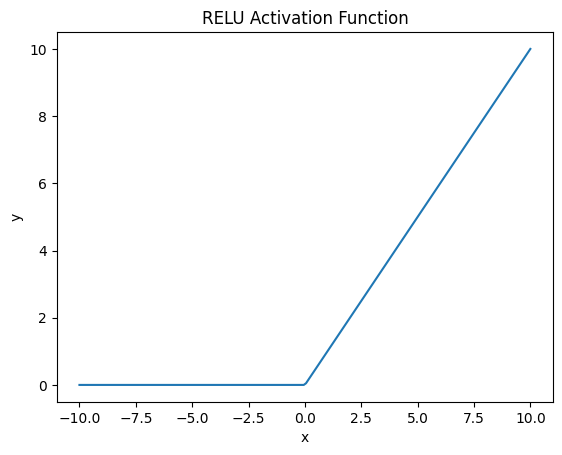

In [13]:
#Helper code to plot the activation function
def plot_activation_func(f, name):
    lin_x = np.linspace(-10,10,200)
    h = f(lin_x)
    plt.plot(lin_x, h)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'{name} Activation Function')

plot_activation_func(relu, name='RELU')

In [14]:
# use your relu activation function on Z1
H = relu(Z1) 

In [15]:
#Use add_ones_col()
H_aug = add_ones_col(H)

#Use np.vstack to add biases to weight matrix
W2 = np.vstack((b2,w2))

#Use np.dot()
Z2 = np.dot(H_aug,W2)

In [16]:
def softmax(z: np.array) -> np.array:
    '''
    Input: z - 2D numpy array of logits 
           rows are observations, classes are columns 
    Returns: y_hat - 2D numpy array of probabilities
             rows are observations, classes are columns 
    '''
    # hint: we are summing across the columns

    y_hat = np.exp(z)/np.sum(np.exp(z), axis=1, keepdims=True)
    return y_hat

In [17]:
#Calling the softmax function
Y_hat = softmax(Z2)

In [18]:
### edTest(test_acc) ###

# Compute the accuracy
y_hat = np.argmax(Y_hat, axis=1)
acc = sum(y == y_hat)/len(y)
print(f'accuracy: {acc:.2%}')

accuracy: 96.67%
